In [1]:
#Importing Libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import efficientnet_b0
from torchvision.models import EfficientNet_B0_Weights

In [2]:
#

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [3]:
#Loade Pretrained EfficientNet

model = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

In [4]:
#

for param in model.features.parameters():
    param.requires_grad = False

In [5]:
#

num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    15
)

In [6]:
#

model = model.to(device)

In [7]:
#

criterion = nn.CrossEntropyLoss()

In [8]:
#optimizer

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

In [9]:
#Training Function

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [10]:
#Validation Pipeline


def validate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    loss = running_loss / len(loader)

    acc = correct / total

    return loss, acc

In [11]:
#
import sys
sys.path.append(r"E:\Laptop\Final_project")

In [12]:
#Data Loading

from src.data_loader import get_dataloaders

dataset_path = r"E:\Laptop\Final_project\Data\PlantVillage"

train_loader, val_loader, test_loader, class_names = get_dataloaders(dataset_path)

In [13]:
#Training Loop

EPOCHS = 5

best_val_acc = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_efficientnet.pth"
        )

Epoch 1/5
Train Acc: 0.7941
Val Acc: 0.9008
Epoch 2/5
Train Acc: 0.8836
Val Acc: 0.9183
Epoch 3/5
Train Acc: 0.9034
Val Acc: 0.9244
Epoch 4/5
Train Acc: 0.9086
Val Acc: 0.9234
Epoch 5/5
Train Acc: 0.9108
Val Acc: 0.9383


In [14]:
model.load_state_dict(
    torch.load("best_efficientnet.pth")
)

<All keys matched successfully>

In [15]:
print(best_val_acc)

0.9382875605815832


In [16]:
model.load_state_dict(
    torch.load(
        "best_efficientnet.pth",
        map_location=device
    )
)

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [18]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9289635130771715


In [19]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.9293987520941178


In [20]:
recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

Recall: 0.9289635130771715


In [21]:
f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

F1 Score: 0.9284348494437888


In [22]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.96      0.96       142
                     Pepper__bell___healthy       0.96      0.99      0.97       218
                      Potato___Early_blight       0.97      0.99      0.98       157
                       Potato___Late_blight       0.93      0.95      0.94       149
                           Potato___healthy       0.89      0.94      0.91        17
                      Tomato_Bacterial_spot       0.91      0.97      0.94       307
                        Tomato_Early_blight       0.79      0.78      0.78       156
                         Tomato_Late_blight       0.88      0.88      0.88       276
                           Tomato_Leaf_Mold       0.90      0.89      0.89       143
                  Tomato_Septoria_leaf_spot       0.95      0.82      0.88       253
Tomato_Spider_mites_Two_spotted_spider_mite       0.92      0.92

In [23]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

import pandas as pd

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "classification_report.csv"
)

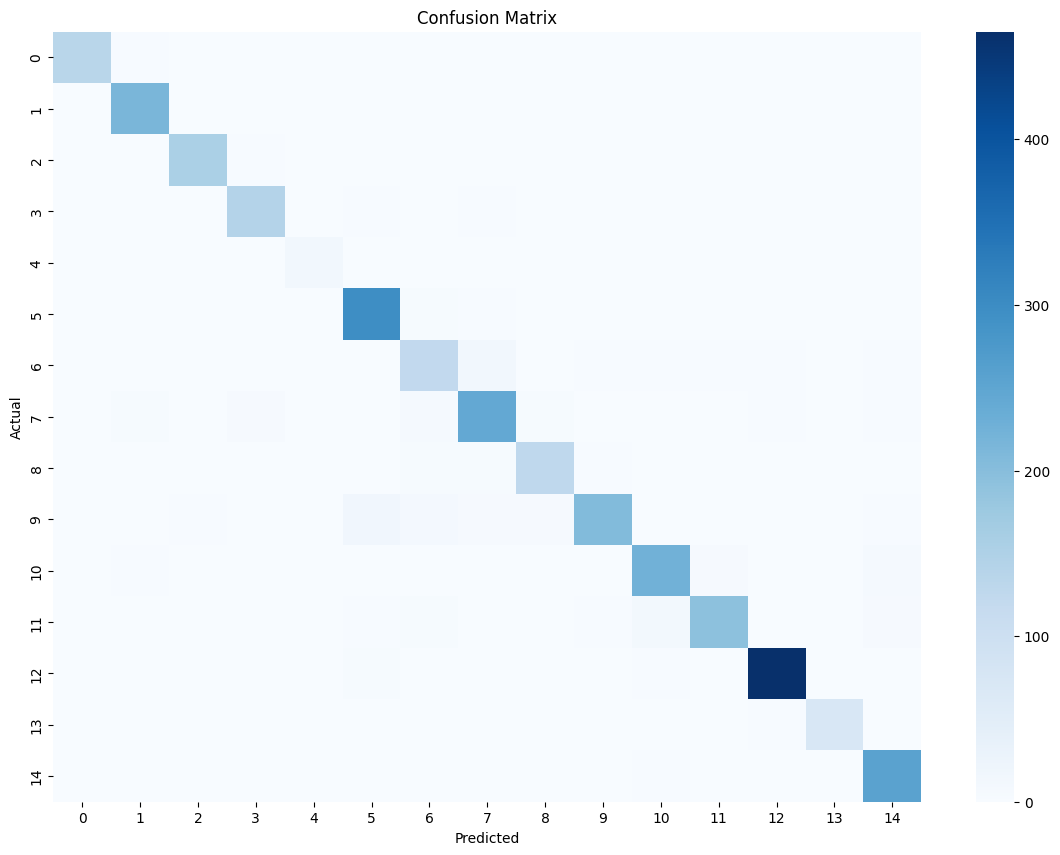

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [25]:
plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [26]:
#